In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/SuperStoreOrders.csv")

In [4]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,StandSard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [5]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [6]:

# 1. Data Preprocessing
# Convert dates to datetime
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True, errors='coerce')
df['ship_date']  = pd.to_datetime(df['ship_date'], format='mixed', dayfirst=True, errors='coerce')


In [7]:
# Extract week and year for alignment with synthetic data
df['week'] = df['order_date'].dt.isocalendar().week
df['year'] = df['order_date'].dt.year

In [8]:
# Clean numeric columns
numeric_cols = ['sales', 'profit', 'shipping_cost', 'quantity', 'discount']
for col in numeric_cols:
    # Remove commas and convert to numeric, setting invalid values to NaN
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')
    # Optionally, fill NaN values (e.g., with 0 or mean)
    df[col] = df[col].fillna(0)

In [9]:
def analyze_numeric_patterns(df, column, group_by=['region', 'week']):
    """Analyze patterns in numeric columns like sales, profit, etc."""
    grouped = df.groupby(group_by)[column].agg(['mean', 'std', 'min', 'max']).reset_index()
    print(f"\nPatterns for {column}:")
    print(grouped.describe())
    return grouped

In [10]:
def analyze_categorical_patterns(df, column, group_by=['region', 'week']):
    """Analyze patterns in categorical columns like ship_mode, segment, etc."""
    counts = df.groupby(group_by + [column]).size().unstack(fill_value=0)
    print(f"\nDistribution for {column}:")
    print(counts.describe())
    return counts

In [11]:
def cluster_analysis(df, features, n_clusters=3):
    """Perform clustering to identify patterns in numeric features"""
    # Select and scale features
    X = df[features].dropna()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df['cluster'] = np.nan
    df.loc[X.index, 'cluster'] = kmeans.fit_predict(X_scaled)
    
    print(f"\nCluster centers for {features}:")
    print(pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features))
    return df


In [12]:
# Numeric patterns (sales, profit, shipping_cost, etc.)
numeric_cols = ['sales', 'profit', 'shipping_cost', 'quantity', 'discount']
for col in numeric_cols:
    analyze_numeric_patterns(df, col)


Patterns for sales:
            week        mean          std         min           max
count      674.0  674.000000   673.000000  674.000000    674.000000
mean   26.522255  248.792483   431.172862    7.544510   2513.047478
std    15.035775   98.516963   235.923431   10.031093   1884.177805
min          1.0   41.400000    28.284271    0.000000     60.000000
25%        13.25  178.709882   285.808658    3.000000   1373.250000
50%         27.0  242.053657   404.578870    6.000000   2193.000000
75%        39.75  299.438690   529.973981    9.000000   3179.500000
max         52.0  768.846154  2262.707377  170.000000  22638.000000

Patterns for profit:
            week        mean         std          min          max
count      674.0  674.000000  673.000000   674.000000   674.000000
mean   26.522255   32.896182  142.647547  -452.139992   720.545797
std    15.035775   31.444770   89.758723   585.569973   709.067648
min          1.0  -56.039863    1.590990 -6599.978000     7.504000
25%       

In [13]:
# Categorical patterns
categorical_cols = ['segment', 'ship_mode', 'category', 'region']
for col in categorical_cols:
    analyze_categorical_patterns(df, col)


Distribution for segment:
segment    Consumer   Corporate  Home Office
count    674.000000  674.000000   674.000000
mean      39.344214   22.891691    13.862018
std       32.281685   19.859054    12.246124
min        0.000000    0.000000     0.000000
25%       18.000000    9.250000     6.000000
50%       31.000000   17.000000    11.000000
75%       52.750000   32.000000    19.000000
max      186.000000  163.000000    78.000000

Distribution for ship_mode:
ship_mode  First Class    Same Day  Second Class  StandSard Class  \
count       674.000000  674.000000    674.000000       674.000000   
mean         11.135015    4.007418     15.295252         0.001484   
std          10.199985    4.576080     13.412212         0.038519   
min           0.000000    0.000000      0.000000         0.000000   
25%           4.000000    0.000000      6.000000         0.000000   
50%           8.000000    3.000000     12.000000         0.000000   
75%          16.000000    6.000000     20.000000        

In [14]:
# 4. Clustering to Identify Patterns
features = ['sales', 'profit', 'shipping_cost']
df = cluster_analysis(df, features)


Cluster centers for ['sales', 'profit', 'shipping_cost']:
         sales      profit  shipping_cost
0   124.632594    4.195986      12.215561
1  2826.767442  712.008581     340.344501
2   963.408083  148.675423     107.648625


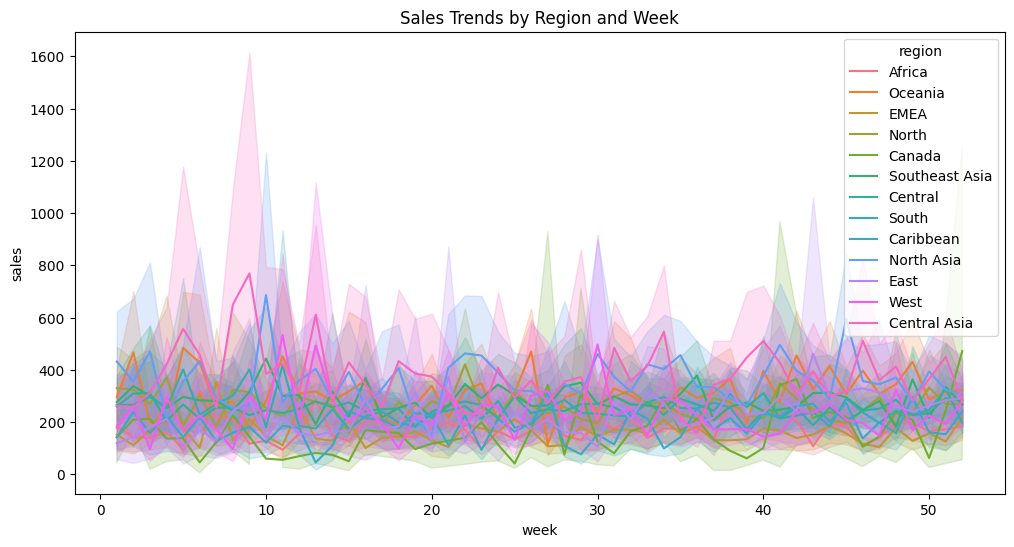

In [15]:
# 5. Visualize Patterns
# Sales trend by region and week
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='week', y='sales', hue='region')
plt.title('Sales Trends by Region and Week')
plt.show()

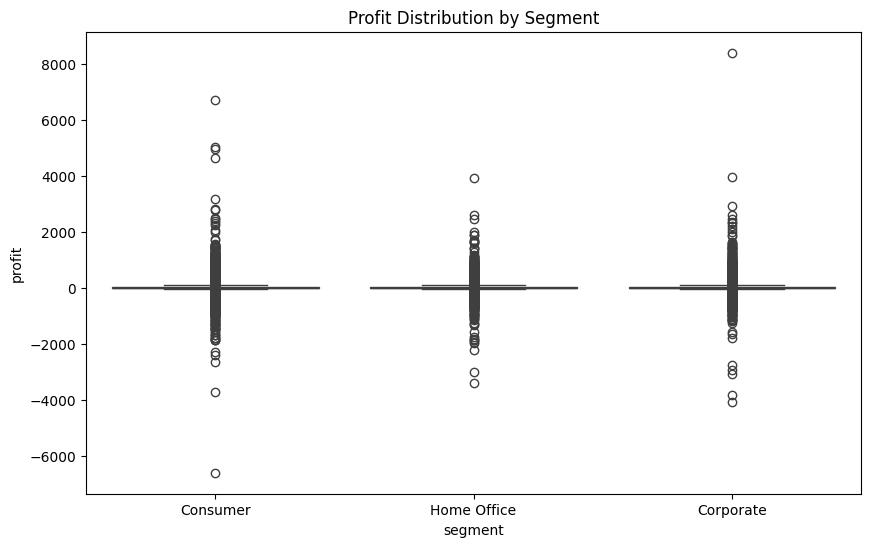

In [16]:
# Profit distribution by segment
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='segment', y='profit')
plt.title('Profit Distribution by Segment')
plt.show()

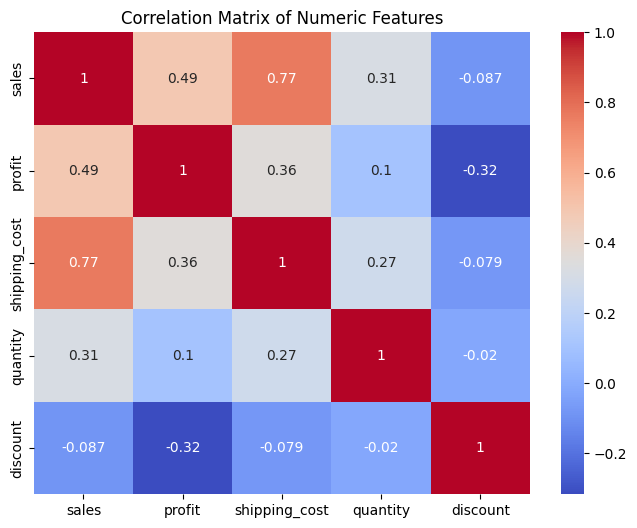

In [17]:
# 6. Correlation Analysis
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [20]:
# Extract year and month from order_date
df['year'] = df['order_date'].dt.year
df['year_month'] = df['order_date'].dt.strftime('%Y-%m')  # Format as 'YYYY-MM'

In [21]:
# Aggregate data by year_month and other categorical columns
agg_df = df.groupby(['year_month', 'region', 'segment', 'ship_mode', 'category']).agg({
    'sales': 'sum',
    'profit': 'sum',
    'shipping_cost': 'sum',
    'quantity': 'sum'
}).reset_index()

In [23]:
# Function to customize x-axis ticks
def customize_xticks(ax, n_labels=10):
    """Limit the number of x-axis labels to improve readability"""
    ticks = ax.get_xticks()
    step = max(1, len(ticks) // n_labels)  # Show approximately n_labels ticks
    ax.set_xticks(ticks[::step])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [24]:
# 1. Time Series Plot: Sales by Region Over Time
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=agg_df, x='year_month', y='sales', hue='region')
plt.title('Sales Trends by Region Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Sales')
customize_xticks(ax)
plt.tight_layout()
plt.savefig('sales_by_region.png')
plt.close()

# 2. Time Series Plot: Profit by Segment Over Time
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=agg_df, x='year_month', y='profit', hue='segment')
plt.title('Profit Trends by Segment Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Profit')
customize_xticks(ax)
plt.tight_layout()
plt.savefig('profit_by_segment.png')
plt.close()

# 3. Time Series Plot: Shipping Cost by Ship Mode Over Time
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=agg_df, x='year_month', y='shipping_cost', hue='ship_mode')
plt.title('Shipping Cost Trends by Ship Mode Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Shipping Cost')
customize_xticks(ax)
plt.tight_layout()
plt.savefig('shipping_cost_by_ship_mode.png')
plt.close()

# 4. Time Series Plot: Quantity by Category Over Time
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=agg_df, x='year_month', y='quantity', hue='category')
plt.title('Quantity Trends by Category Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Quantity')
customize_xticks(ax)
plt.tight_layout()
plt.savefig('quantity_by_category.png')
plt.close()

# 5. Aggregated Time Series Plot: Total Sales by Year-Month
total_sales = agg_df.groupby('year_month')['sales'].sum().reset_index()
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=total_sales, x='year_month', y='sales')
plt.title('Total Sales Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales')
customize_xticks(ax)
plt.tight_layout()
plt.savefig('total_sales.png')
plt.close()

print("Time series plots generated and saved as PNG files with monthly aggregation.")

Time series plots generated and saved as PNG files with monthly aggregation.
